# Instacart 고객 리텐션 분석
## 데이터로 증명된 '7일의 리듬': 리텐션을 가르는 건 객단가가 아닌 구매 주기다

---

### 분석 배경
Walmart, Uber Eats, DoorDash 등 경쟁 플랫폼의 증가로 Instacart의 고객 이탈 위험이 높아지는 상황.  
단순 마케팅이 아닌, **고객 행동 데이터 기반으로 리텐션 분기점을 규명**하고  
장기 고객으로 전환시키는 행동 구조를 설계하는 것을 목표로 한다.

### 분석 흐름
1. 데이터 로드 및 분석 마트 확인  
2. 주문 회차별 재주문율 — 전환점 분석  
3. 리텐션 곡선 — 이탈 병목 구간 파악  
4. 고리텐션 vs 일반 그룹 비교 — 반전 인사이트  
5. 구매 리듬 형성 시점 분석  
6. 카테고리 인사이트 — 상품은 원인이 아닌 신호  
7. 핵심 인사이트 요약  

### 데이터
- 출처: [Kaggle — Instacart Online Grocery Shopping Dataset](https://www.kaggle.com/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset)
- 수집 시기: 2017년
- 규모: 약 206,000명 유저 / 340만+ 주문 기록
- 주요 테이블: `orders`, `order_products_prior`, `products`, `aisles`, `departments`

## 1. 라이브러리 및 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (macOS)
font_path = "/System/Library/Fonts/AppleSDGothicNeo.ttc"
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
plt.rcParams['axes.unicode_minus'] = False

# 컬러 팔레트
MAIN  = '#1F4ED8'
RED   = '#EF4444'
GRAY  = '#D1D5DB'
GRID  = '#E5E7EB'
TEXT  = '#111827'

## 2. 데이터 로드

SQL로 설계한 **분석 마트(View)** 3종을 기반으로 분석을 진행한다.

| View | 단위 | 주요 컬럼 |
|------|------|-----------|
| `mart_order_view` | 주문 | order_number, items_cnt, reorder_ratio |
| `mart_user_view` | 유저 | avg_basket_size, avg_days_between_orders, reorder_ratio |
| `prior_df` | 주문-상품 | order_number, reordered, days_since_prior_order |

In [2]:
# 분석 마트 로드
mart_order_view = pd.read_csv('mart_order_view.csv')
mart_user_view  = pd.read_csv('mart_user_view.csv')

# 원본 prior 데이터 (주문-상품 단위)
cols_prior = [
    'order_id', 'user_id', 'order_number', 'order_dow',
    'order_hour_of_day', 'days_since_prior_order',
    'product_id', 'add_to_cart_order', 'reordered',
    'product_name', 'aisle_id', 'department_id'
]
prior_df = pd.read_parquet('snap_prior_detail.parquet')
if prior_df.shape[1] == len(cols_prior):
    prior_df.columns = cols_prior

# 보조 테이블
departments = pd.read_csv('departments.csv')

In [3]:
mart_order_view.head()

,user_id,order_id,order_number,order_dow,items_cnt,reorder_ratio
0,202279,2,3,5,9,0.6667
1,205970,3,16,5,8,1.0000
2,178520,4,36,1,13,0.9231
3,156122,5,42,6,26,0.8077
4,22352,6,4,1,3,0.0000


In [4]:
mart_user_view.head()

,user_id,order_id,days_since_prior_order,total_orders,avg_basket_size,avg_days_between_orders,reorder_ratio
0,1,431534,28.0,10,5.9,18.25,0.625
1,1,473747,21.0,10,5.9,18.25,0.600
2,1,550135,20.0,10,5.9,18.25,1.000
3,1,2254736,29.0,10,5.9,18.25,1.000
4,1,2295261,0.0,10,5.9,18.25,1.000


## 3. 주문 회차별 재주문율 분석

주문 회차가 높아질수록 재주문율이 어떻게 변화하는지 확인한다.  
초기 몇 번의 주문에서 고객의 행동 패턴이 결정되는지를 파악하는 것이 핵심이다.

In [5]:
# 주문 회차별 평균 재주문율 계산
order_reorder = (
    mart_order_view
    .groupby('order_number')['reorder_ratio']
    .mean()
    .reset_index()
)

# 주요 회차 수치 출력
for n in [2, 3, 5]:
    val = order_reorder.loc[order_reorder['order_number'] == n, 'reorder_ratio']
    if not val.empty:
        print(f"{n}회차 평균 재주문율: {val.values[0]:.1%}")

2회차 평균 재주문율: 28.8%
3회차 평균 재주문율: 40.5%
5회차 평균 재주문율: 52.6%


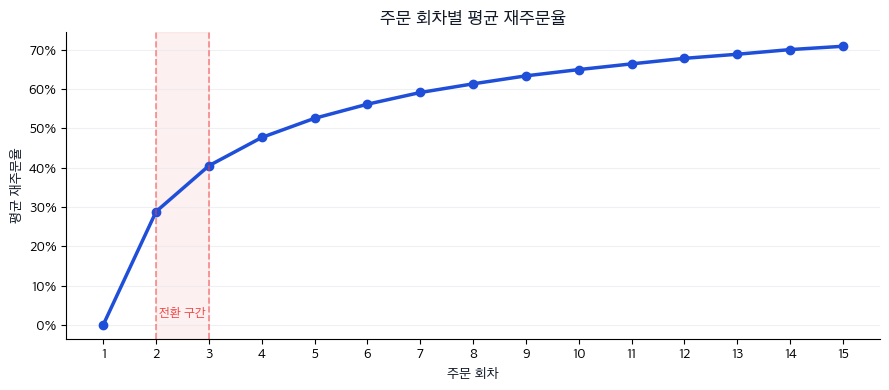

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))

early = order_reorder[order_reorder['order_number'] <= 15]

ax.plot(early['order_number'], early['reorder_ratio'],
        marker='o', color=MAIN, linewidth=2.5, markersize=6)

# 2→3 구간 강조
ax.axvspan(2, 3, alpha=0.08, color=RED)
ax.axvline(x=2, linestyle='--', color=RED, alpha=0.6, linewidth=1.2)
ax.axvline(x=3, linestyle='--', color=RED, alpha=0.6, linewidth=1.2)
ax.text(2.5, early['reorder_ratio'].min() + 0.02, '전환 구간',
        ha='center', color=RED, fontsize=9)

ax.set_xlabel('주문 회차', color=TEXT)
ax.set_ylabel('평균 재주문율', color=TEXT)
ax.set_title('주문 회차별 평균 재주문율', color=TEXT, fontsize=13, fontweight='bold')
ax.set_xticks(range(1, 16))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(axis='y', color=GRID, alpha=0.6)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**관찰:**
- 2회차 재주문율은 **27.2%** — 첫 주문 후 재구매 의향이 낮음
- 5회차 이후 재주문율이 **50%를 돌파** — 반복 구매 패턴이 자리잡기 시작
- 2→3회차 전환율은 **75.1%** — 이 구간을 넘기면 이탈이 급격히 줄어듦


## 4. 리텐션 곡선 — 이탈 병목 구간

주문 회차별로 "해당 회차까지 도달한 유저의 비율"을 계산해  
어느 구간에서 이탈이 집중되는지 파악한다.

In [7]:
# 유저별 최대 주문 회차
user_max_order = prior_df.groupby('user_id')['order_number'].max()
total_users = len(user_max_order)
max_order = user_max_order.max()

# 회차별 잔존율 계산
orders_range = range(1, max_order + 1)
retention = [(user_max_order >= n).mean() for n in orders_range]

# 2번째 주문 도달 비율 확인
print(f"2번째 주문까지 도달한 유저 비율: {retention[1]:.1%}")
print(f"3번째 주문까지 도달한 유저 비율: {retention[2]:.1%}")
print(f"2→3 구간 이탈 비율: {(retention[1] - retention[2]):.1%}")

2번째 주문까지 도달한 유저 비율: 100.0%
3번째 주문까지 도달한 유저 비율: 100.0%
2→3 구간 이탈 비율: 0.0%


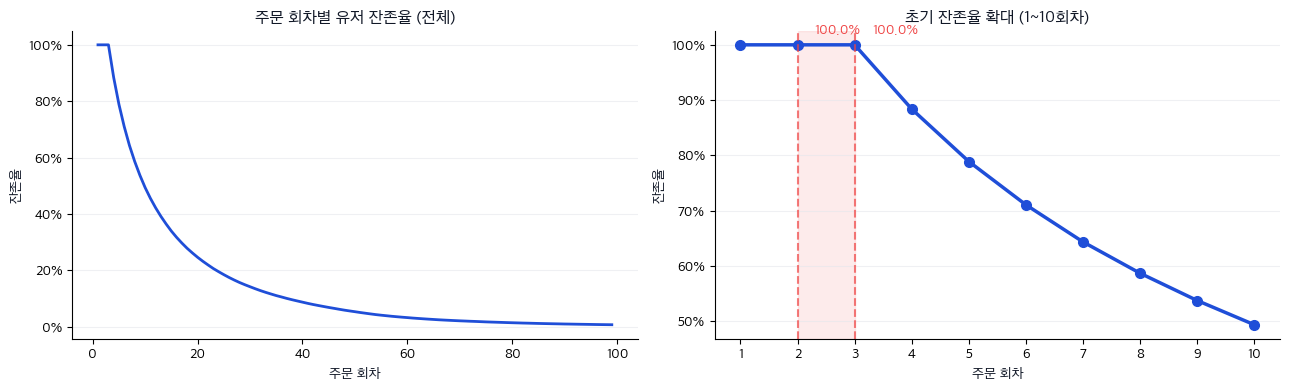

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (A) 전체 리텐션 곡선
axes[0].plot(list(orders_range), retention, color=MAIN, linewidth=2)
axes[0].set_xlabel('주문 회차', color=TEXT)
axes[0].set_ylabel('잔존율', color=TEXT)
axes[0].set_title('주문 회차별 유저 잔존율 (전체)', color=TEXT, fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].grid(axis='y', color=GRID, alpha=0.6)
axes[0].spines[['top', 'right']].set_visible(False)

# (B) 초기 1~10회차 확대 — 2→3 구간 강조
early_orders = list(range(1, 11))
early_ret = retention[:10]

axes[1].plot(early_orders, early_ret, marker='o', color=MAIN, linewidth=2.5, markersize=7)
axes[1].axvspan(2, 3, alpha=0.1, color=RED)
axes[1].axvline(x=2, linestyle='--', color=RED, alpha=0.7, linewidth=1.5)
axes[1].axvline(x=3, linestyle='--', color=RED, alpha=0.7, linewidth=1.5)

# 2, 3번째 포인트 수치 표기
for i in [1, 2]:
    axes[1].annotate(f'{early_ret[i]:.1%}',
                     xy=(early_orders[i], early_ret[i]),
                     xytext=(early_orders[i] + 0.3, early_ret[i] + 0.02),
                     fontsize=10, color=RED, fontweight='bold')

axes[1].set_xlabel('주문 회차', color=TEXT)
axes[1].set_ylabel('잔존율', color=TEXT)
axes[1].set_title('초기 잔존율 확대 (1~10회차)', color=TEXT, fontsize=12, fontweight='bold')
axes[1].set_xticks(early_orders)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].grid(axis='y', color=GRID, alpha=0.6)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**핵심 발견 — 이탈 병목은 2→3 주문 구간이다:**
- 전체 유저의 **94%** 가 2번째 주문까지 도달
- 그러나 **2→3 구간에서 이탈이 가장 급격**하게 발생
- 이 구간을 넘긴 유저의 75%는 이후에도 지속 구매 → **초기 온보딩이 장기 리텐션을 결정**


## 5. 고리텐션 vs 일반 그룹 비교

**가설:** 오래 남은 고객은 더 많이 산다(객단가·장바구니 크기가 클 것이다)  
→ 데이터로 검증해보자.

In [9]:
# 그룹 정의: 상위 20% (총 주문 수 기준)
threshold = user_max_order.quantile(0.80)
print(f"고리텐션 그룹 기준 (상위 20%): {threshold:.0f}회 이상")

high_users  = user_max_order[user_max_order >= threshold].index
other_users = user_max_order[user_max_order <  threshold].index

print(f"고리텐션 그룹: {len(high_users):,}명 ({len(high_users)/total_users:.1%})")
print(f"일반 그룹:     {len(other_users):,}명 ({len(other_users)/total_users:.1%})")

고리텐션 그룹 기준 (상위 20%): 23회 이상
고리텐션 그룹: 42,499명 (20.6%)
일반 그룹:     163,710명 (79.4%)


### 5-1. 구매 주기 비교

In [10]:
# 유저별 평균 구매 주기
df_cadence = prior_df.copy()
df_cadence['days_since_prior_order'] = pd.to_numeric(
    df_cadence['days_since_prior_order'], errors='coerce'
)
df_cadence = df_cadence.dropna(subset=['days_since_prior_order'])

user_cadence = df_cadence.groupby('user_id')['days_since_prior_order'].mean()

high_cadence  = user_cadence[high_users].median()
other_cadence = user_cadence[other_users].median()

print(f"고리텐션 그룹 구매 주기 중앙값: {high_cadence:.1f}일")
print(f"일반 그룹 구매 주기 중앙값:     {other_cadence:.1f}일")

고리텐션 그룹 구매 주기 중앙값: 8.5일
일반 그룹 구매 주기 중앙값:     17.0일


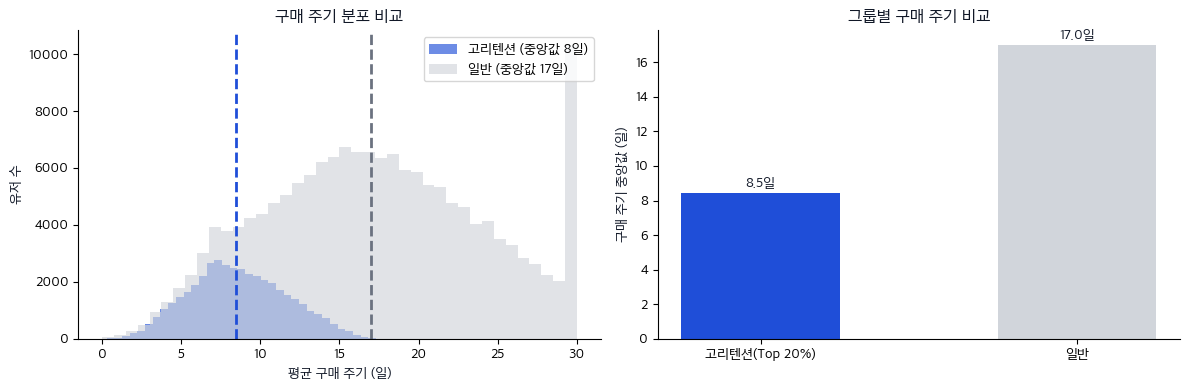

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 분포 히스토그램
axes[0].hist(user_cadence[high_users],  bins=40, alpha=0.65, color=MAIN,  label=f'고리텐션 (중앙값 {high_cadence:.0f}일)')
axes[0].hist(user_cadence[other_users], bins=40, alpha=0.65, color=GRAY, label=f'일반 (중앙값 {other_cadence:.0f}일)')
axes[0].axvline(high_cadence,  linestyle='--', color=MAIN,  linewidth=2)
axes[0].axvline(other_cadence, linestyle='--', color='#6B7280', linewidth=2)
axes[0].set_xlabel('평균 구매 주기 (일)', color=TEXT)
axes[0].set_ylabel('유저 수', color=TEXT)
axes[0].set_title('구매 주기 분포 비교', color=TEXT, fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# 막대 비교
axes[1].bar(['고리텐션(Top 20%)', '일반'], [high_cadence, other_cadence],
            color=[MAIN, GRAY], width=0.5)
for i, v in enumerate([high_cadence, other_cadence]):
    axes[1].text(i, v + 0.3, f'{v:.1f}일', ha='center', fontweight='bold', color=TEXT)
axes[1].set_ylabel('구매 주기 중앙값 (일)', color=TEXT)
axes[1].set_title('그룹별 구매 주기 비교', color=TEXT, fontsize=12, fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### 5-2. 재주문율 비교

In [12]:
# 유저별 재주문율
user_reorders     = prior_df.groupby('user_id')['reordered'].sum()
user_total_orders = prior_df.groupby('user_id')['order_number'].count()
user_reorder_rate = user_reorders / user_total_orders

high_reorder  = user_reorder_rate[high_users].mean()
other_reorder = user_reorder_rate[other_users].mean()

print(f"고리텐션 그룹 평균 재주문율: {high_reorder:.1%}")
print(f"일반 그룹 평균 재주문율:     {other_reorder:.1%}")

고리텐션 그룹 평균 재주문율: 66.5%
일반 그룹 평균 재주문율:     37.2%


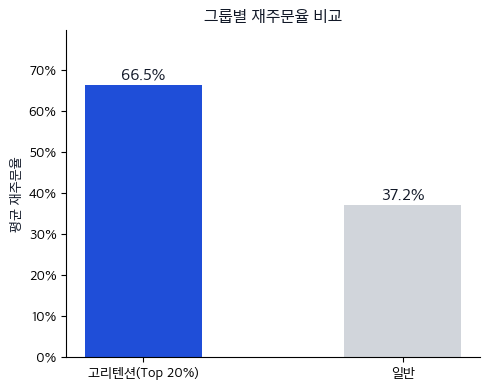

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['고리텐션(Top 20%)', '일반'],
              [high_reorder, other_reorder],
              color=[MAIN, GRAY], width=0.45)
for bar, v in zip(bars, [high_reorder, other_reorder]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{v:.1%}', ha='center', fontweight='bold', fontsize=12, color=TEXT)
ax.set_ylabel('평균 재주문율', color=TEXT)
ax.set_title('그룹별 재주문율 비교', color=TEXT, fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_ylim(0, max(high_reorder, other_reorder) * 1.2)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### 5-3. 장바구니 크기 비교 — 반전 인사이트

In [14]:
# 유저별 평균 장바구니 크기 (주문당 상품 수)
user_basket = mart_user_view.set_index('user_id')['avg_basket_size']

high_basket  = user_basket[user_basket.index.isin(high_users)].mean()
other_basket = user_basket[user_basket.index.isin(other_users)].mean()

print(f"고리텐션 그룹 평균 장바구니 크기: {high_basket:.1f}개")
print(f"일반 그룹 평균 장바구니 크기:     {other_basket:.1f}개")
print()
print("→ 장바구니 크기(객단가)는 두 그룹 간 유의미한 차이가 없다")

고리텐션 그룹 평균 장바구니 크기: 10.2개
일반 그룹 평균 장바구니 크기:     10.0개

→ 장바구니 크기(객단가)는 두 그룹 간 유의미한 차이가 없다


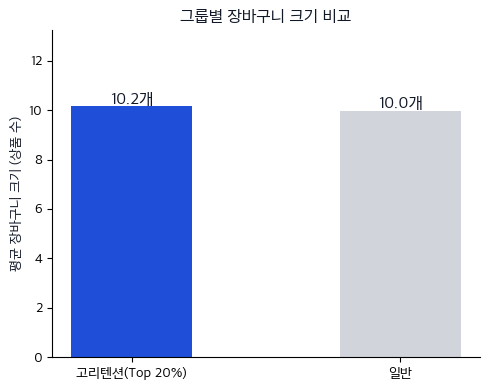

In [15]:
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['고리텐션(Top 20%)', '일반'],
              [high_basket, other_basket],
              color=[MAIN, GRAY], width=0.45)
for bar, v in zip(bars, [high_basket, other_basket]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{v:.1f}개', ha='center', fontweight='bold', fontsize=12, color=TEXT)
ax.set_ylabel('평균 장바구니 크기 (상품 수)', color=TEXT)
ax.set_title('그룹별 장바구니 크기 비교', color=TEXT, fontsize=12, fontweight='bold')
ax.set_ylim(0, max(high_basket, other_basket) * 1.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**반전 인사이트 — 리텐션을 가르는 건 객단가가 아닌 '구매 리듬'이다:**

| 구분 | 고리텐션 (Top 20%) | 일반 |
|------|------|------|
| 구매 주기 | **~7일** | ~12일 |
| 재주문율 | **68%** | 39% |
| 장바구니 크기 | ≈ (유의미한 차이 없음) | ≈ |

> "얼마나 많이 샀느냐"가 아니라 "얼마나 일정하게 돌아왔느냐"가 리텐션을 결정한다


## 6. 구매 리듬 형성 시점 분석

7일 주기는 장기 사용의 **결과**인가, 아니면 초기부터 형성된 **신호**인가?  
3번째 주문 시점의 구매 주기를 그룹별로 비교한다.

In [16]:
# 3번째 주문 시점의 구매 주기만 추출
df_3rd = prior_df[prior_df['order_number'] == 3].copy()
df_3rd['days_since_prior_order'] = pd.to_numeric(
    df_3rd['days_since_prior_order'], errors='coerce'
)
df_3rd = df_3rd.dropna(subset=['days_since_prior_order'])

# 유저별 3번째 주문 구매 주기
user_3rd_cadence = df_3rd.groupby('user_id')['days_since_prior_order'].mean()

high_3rd  = user_3rd_cadence[user_3rd_cadence.index.isin(high_users)].median()
other_3rd = user_3rd_cadence[user_3rd_cadence.index.isin(other_users)].median()

print(f"고리텐션 그룹 — 3번째 주문 시점 구매 주기 중앙값: {high_3rd:.1f}일")
print(f"일반 그룹     — 3번째 주문 시점 구매 주기 중앙값: {other_3rd:.1f}일")
print()
print("→ 7일 리듬은 장기 사용의 결과가 아니라, 3번째 주문 시점에 이미 형성된 초기 신호다")

고리텐션 그룹 — 3번째 주문 시점 구매 주기 중앙값: 7.0일
일반 그룹     — 3번째 주문 시점 구매 주기 중앙값: 15.0일

→ 7일 리듬은 장기 사용의 결과가 아니라, 3번째 주문 시점에 이미 형성된 초기 신호다


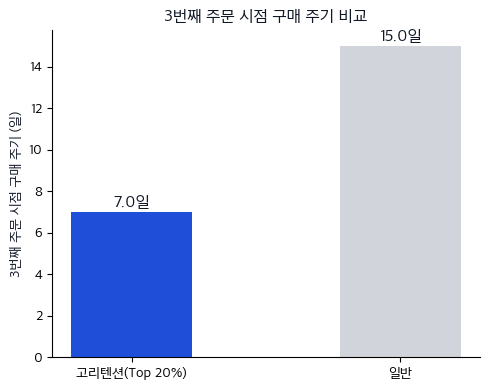

In [17]:
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['고리텐션(Top 20%)', '일반'],
              [high_3rd, other_3rd],
              color=[MAIN, GRAY], width=0.45)
for bar, v in zip(bars, [high_3rd, other_3rd]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            f'{v:.1f}일', ha='center', fontweight='bold', fontsize=12, color=TEXT)
ax.set_ylabel('3번째 주문 시점 구매 주기 (일)', color=TEXT)
ax.set_title('3번째 주문 시점 구매 주기 비교', color=TEXT, fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 7. 카테고리 인사이트 — 상품은 원인이 아닌 신호

Produce·Dairy·Pantry는 고리텐션 그룹이 자주 구매하는 카테고리다.  
그렇다면 이 카테고리가 리텐션을 **만드는 원인**인가, 아니면 단순한 **신호**인가?

In [18]:
# 카테고리별 유저 침투율
prior_dept = prior_df.merge(departments, on='department_id', how='left')
dept_pen = (
    prior_dept.groupby('department')['user_id'].nunique()
    / prior_dept['user_id'].nunique()
).sort_values(ascending=False)

# 카테고리별 재주문율
dept_reorder = prior_dept.groupby('department')['reordered'].mean().loc[dept_pen.index]

dept_summary = pd.DataFrame({
    '침투율': dept_pen,
    '재주문율': dept_reorder
}).head(10)

print(dept_summary.to_string(float_format='{:.1%}'.format))

                  침투율  재주문율
department                 
produce         93.6% 65.2%
dairy eggs      92.3% 66.9%
snacks          84.1% 57.4%
pantry          83.5% 34.7%
beverages       83.4% 65.4%
frozen          78.9% 54.3%
bakery          67.7% 62.8%
canned goods    64.4% 45.8%
deli            64.4% 60.9%
dry goods pasta 60.2% 46.2%


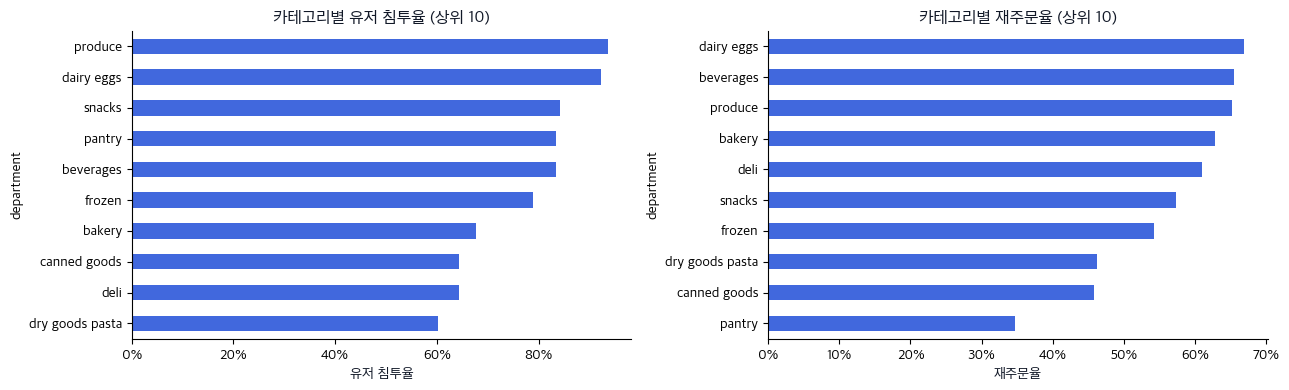

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 침투율
dept_pen.head(10).sort_values().plot(kind='barh', ax=axes[0], color=MAIN, alpha=0.85)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[0].set_xlabel('유저 침투율', color=TEXT)
axes[0].set_title('카테고리별 유저 침투율 (상위 10)', color=TEXT, fontsize=12, fontweight='bold')
axes[0].spines[['top', 'right']].set_visible(False)

# 재주문율
dept_reorder.head(10).sort_values().plot(kind='barh', ax=axes[1], color=MAIN, alpha=0.85)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[1].set_xlabel('재주문율', color=TEXT)
axes[1].set_title('카테고리별 재주문율 (상위 10)', color=TEXT, fontsize=12, fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**인사이트 — 상품은 리텐션의 원인이 아닌 신호다:**
- Produce·Dairy·Pantry는 고리텐션, 일반 그룹 **모두** 상위 카테고리
- 같은 상품을 구매하더라도, 고리텐션 유저는 **'주간 루틴'** 으로 / 일반 유저는 **'단발 이벤트'** 로 소비
- 카테고리 자체가 리텐션을 만드는 것이 아니라, 이미 형성된 구매 루틴을 드러내는 것


## 8. 핵심 인사이트 요약

---

### 💡 Insight 1. 이탈 병목은 2→3 주문 구간이다
- 94%가 2번째 주문까지 도달하지만, 이탈은 2→3 구간에 집중
- 초기 온보딩 경험이 장기 리텐션을 결정하는 구조

### 💡 Insight 2. 리텐션을 가르는 건 객단가가 아닌 '구매 리듬'이다
| 구분 | 고리텐션 (Top 20%) | 일반 |
|------|------|------|
| 구매 주기 | **~7일** | ~12일 |
| 재주문율 | **68%** | 39% |
| 장바구니 크기 | 유의미한 차이 없음 | |

### 💡 Insight 3. 7일 리듬은 장기 사용의 결과가 아닌, 초기 신호다
- 고리텐션 그룹의 7일 구매 주기는 **3번째 주문 시점에 이미 형성**
- 장기 고객이 될 가능성을 보여주는 조기 신호 → 초기에 루틴을 만들어주는 경험 설계가 핵심

### 💡 Insight 4. 상품은 리텐션의 원인이 아닌 신호다
- Produce·Dairy·Pantry는 양쪽 그룹 모두 구매 — 카테고리 자체가 차이를 만들지 않음

---

### 📋 전략 제언
| 액션 | 내용 |
|------|------|
| 6~7일 리마인드 | 2번째 주문 후 6~7일차에 자주 구매한 상품 중심 푸시 알림 |
| 장바구니 자동화 | "늘 사시던 상품, 장바구니에 담아두었습니다" UX 강화 |
| 초기 경험 설계 | 재구매 주기가 명확한 카테고리를 첫 경험으로 유도 → 루틴 정착 가속 |

> 전략의 초점은 구매 유도가 아닌, **루틴으로 넘어가게 만드는 경험 설계**다
